# Customer Churn Prediction\n\n## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")


## 2. Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('../data/raw/churn_data.csv')
print(f"Dataset Shape: {df.shape}")
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Dataset Shape: (10000, 14)

Data Types:
 RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicates: 0


In [3]:
# Handle any missing values/duplicates
# The dataset has no missing values or duplicates, but we will add defensive code.
df = df.drop_duplicates()
df = df.dropna()
print(f"Shape after cleaning: {df.shape}")


Shape after cleaning: (10000, 14)


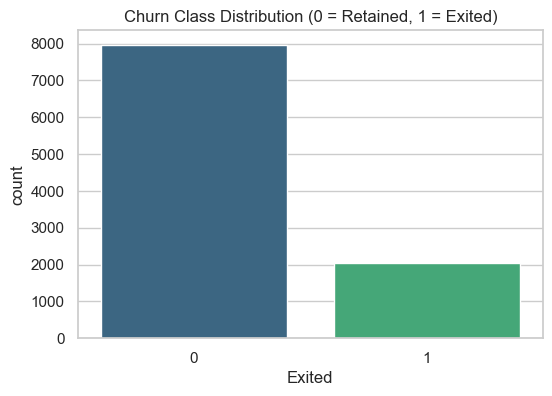

Takeaway: The dataset is highly imbalanced, with a much larger proportion of retained customers compared to those who exited.


In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Exited', palette='viridis')
plt.title('Churn Class Distribution (0 = Retained, 1 = Exited)')
plt.savefig('../outputs/figures/eda_1_class_dist.png', bbox_inches='tight')
plt.show()

print("Takeaway: The dataset is highly imbalanced, with a much larger proportion of retained customers compared to those who exited.")


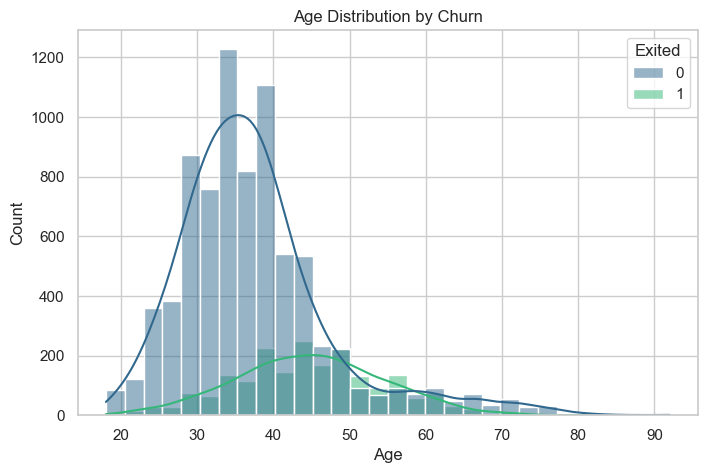

Takeaway: Older customers (around 40-60 years old) are significantly more likely to churn compared to younger customers.


In [5]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, palette='viridis', bins=30)
plt.title('Age Distribution by Churn')
plt.savefig('../outputs/figures/eda_2_age_dist.png', bbox_inches='tight')
plt.show()

print("Takeaway: Older customers (around 40-60 years old) are significantly more likely to churn compared to younger customers.")


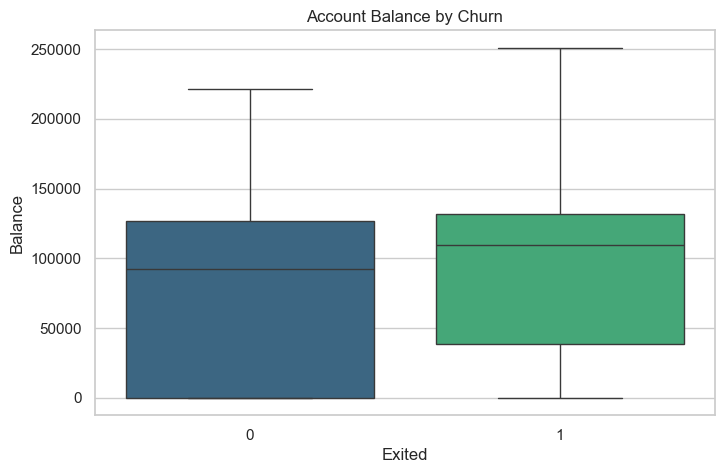

Takeaway: Customers who churned tend to have a slightly higher median account balance, suggesting that wealthier clients might be leaving.


In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Exited', y='Balance', palette='viridis')
plt.title('Account Balance by Churn')
plt.savefig('../outputs/figures/eda_3_balance.png', bbox_inches='tight')
plt.show()

print("Takeaway: Customers who churned tend to have a slightly higher median account balance, suggesting that wealthier clients might be leaving.")


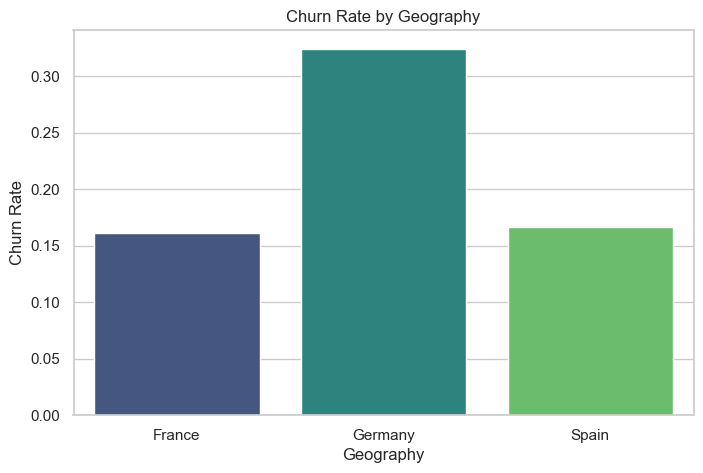

Takeaway: Customers in Germany have a noticeably higher churn rate compared to those in France and Spain.


In [7]:
plt.figure(figsize=(8,5))
geo_churn = df.groupby('Geography')['Exited'].mean().reset_index()
sns.barplot(data=geo_churn, x='Geography', y='Exited', palette='viridis')
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate')
plt.savefig('../outputs/figures/eda_4_geography.png', bbox_inches='tight')
plt.show()

print("Takeaway: Customers in Germany have a noticeably higher churn rate compared to those in France and Spain.")


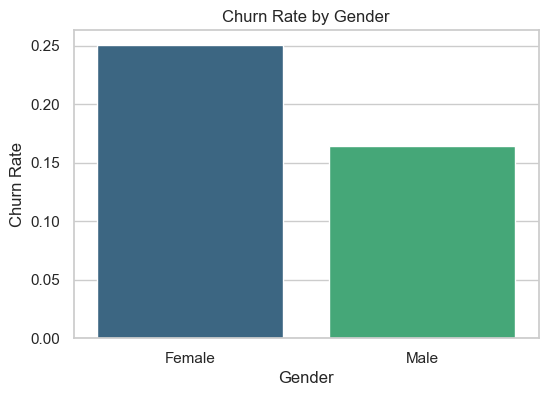

Takeaway: Female customers churn at a higher rate than male customers.


In [8]:
plt.figure(figsize=(6,4))
gender_churn = df.groupby('Gender')['Exited'].mean().reset_index()
sns.barplot(data=gender_churn, x='Gender', y='Exited', palette='viridis')
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.savefig('../outputs/figures/eda_5_gender.png', bbox_inches='tight')
plt.show()

print("Takeaway: Female customers churn at a higher rate than male customers.")


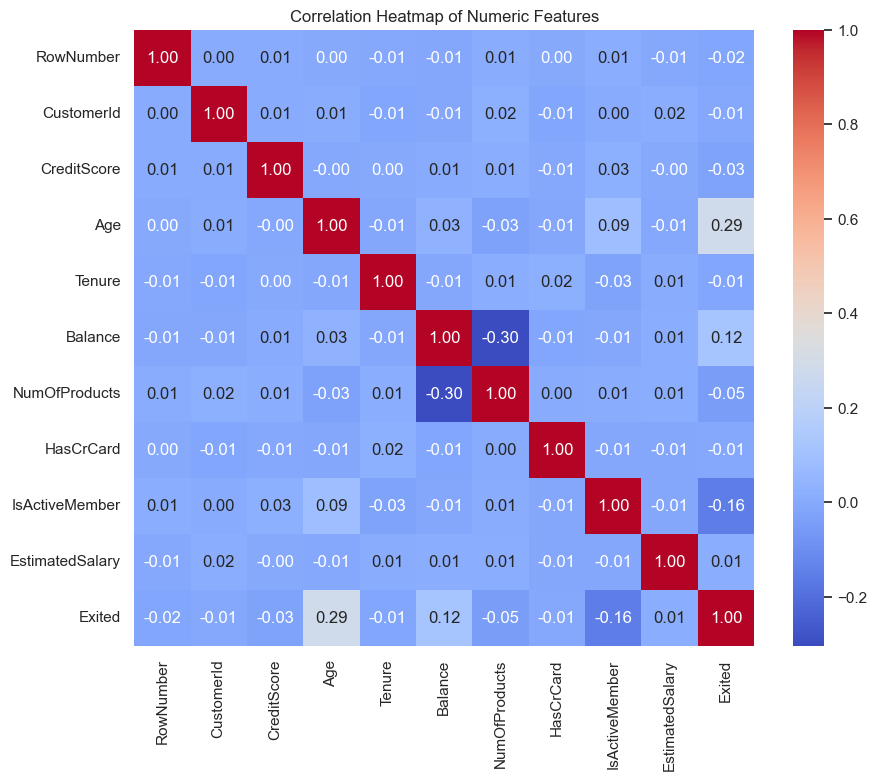

Takeaway: Age is the numeric feature most strongly correlated with churning, while other features show weak linear relationships.


In [9]:
plt.figure(figsize=(10,8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('../outputs/figures/eda_6_heatmap.png', bbox_inches='tight')
plt.show()

print("Takeaway: Age is the numeric feature most strongly correlated with churning, while other features show weak linear relationships.")


## 3. Preprocessing

In [10]:
# Drop identifier columns
# CustomerId, Surname, and RowNumber are unique identifiers that hold no predictive power and could lead to overfitting.
df_processed = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode categorical variables using one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=['Geography', 'Gender'], drop_first=True)

# Separate features and target
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale numeric features
# Scaling is crucial for Logistic Regression because it's distance-based; features with larger scales would otherwise dominate the regularization penalty.
scaler = StandardScaler()
numeric_features = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'CreditScore']
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Save processed dataset
df_processed.to_csv('../data/processed/processed_churn_data.csv', index=False)
print("Processed dataset saved to data/processed/")


Processed dataset saved to data/processed/


## 4. Modeling

In [11]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
trained_models = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).round(4)
print(results_df)

# Save metrics for report
results_df.to_csv('../outputs/models/metrics.csv', index=False)


                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.808     0.5891  0.1867    0.2836   0.7748
1        Random Forest     0.864     0.7824  0.4595    0.5789   0.8522
2              XGBoost     0.849     0.6829  0.4816    0.5648   0.8328


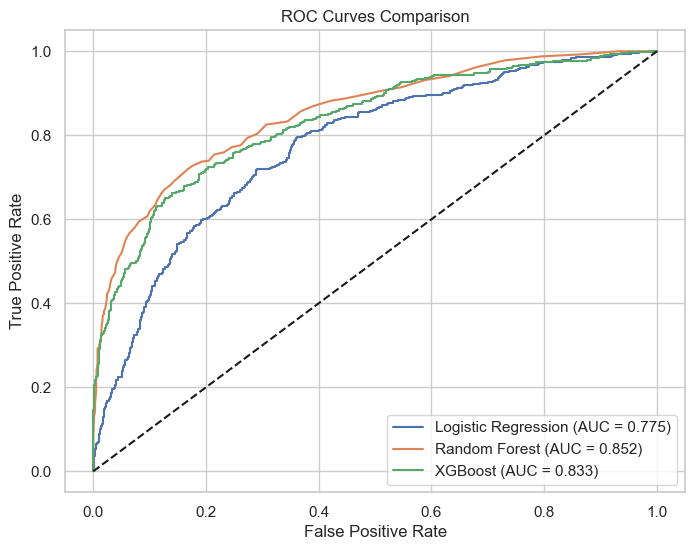

In [12]:
plt.figure(figsize=(8,6))
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.savefig('../outputs/figures/roc_curves.png', bbox_inches='tight')
plt.show()


Best Model: Random Forest


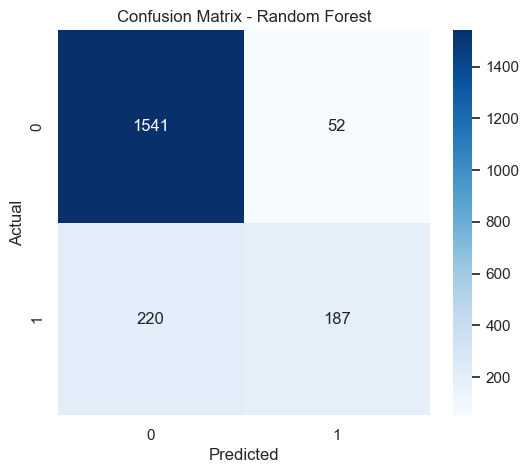

Best model saved to outputs/models/best_model.pkl


In [13]:
# Find best model based on ROC-AUC
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.savefig('../outputs/figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

# Save best model
joblib.dump(best_model, '../outputs/models/best_model.pkl')
print(f"Best model saved to outputs/models/best_model.pkl")


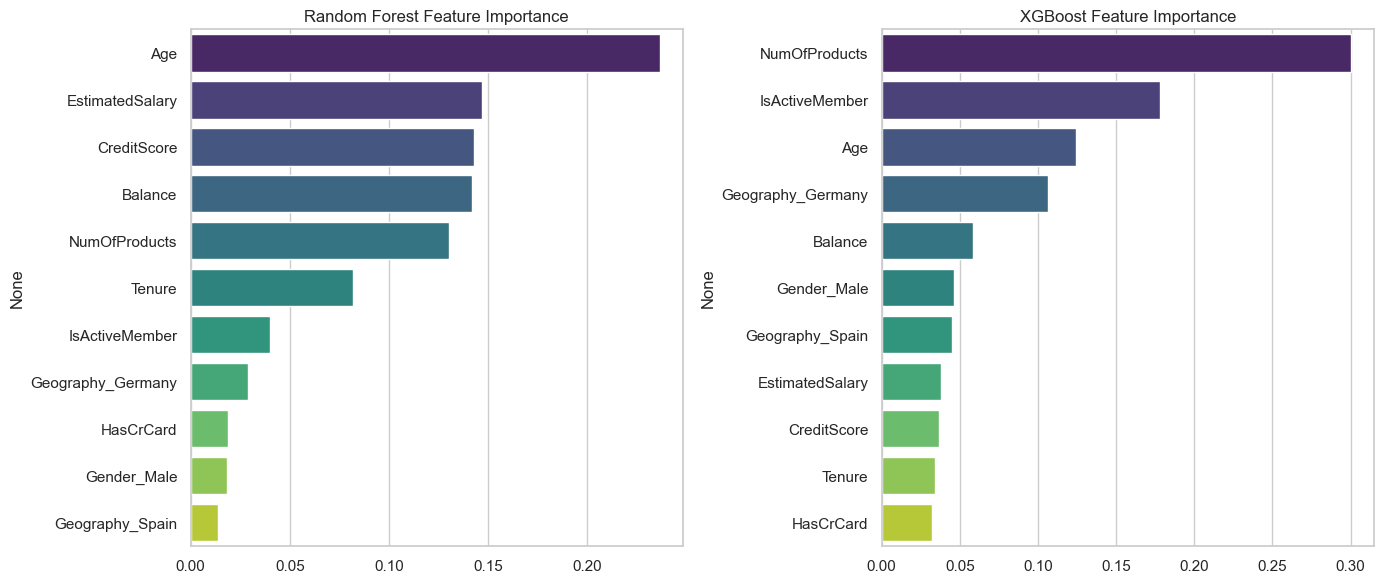

Takeaway: Age, NumOfProducts, and Balance are the strongest drivers of churn according to both tree-based models.


In [14]:
# Plot feature importances for Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, model_name in enumerate(["Random Forest", "XGBoost"]):
    model = trained_models[model_name]
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    features = X_train.columns[indices]
    
    sns.barplot(x=importances[indices], y=features, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{model_name} Feature Importance')

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', bbox_inches='tight')
plt.show()

print("Takeaway: Age, NumOfProducts, and Balance are the strongest drivers of churn according to both tree-based models.")
